<a href="https://colab.research.google.com/github/FBenita/Clinic_Staffing_DES_GA/blob/main/01_nominal_problem_and_benchmarking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 1 — Nominal Problem & Algorithm Benchmarking

**Companion code for:** *Robust Staffing of Walk-In Clinics under Demand Uncertainty: A Simulation-Optimization Approach with Exact Benchmarking* (Francisco Benita, Tecnológico de Monterrey)

This notebook is self-contained: running every cell top to bottom regenerates, from
scratch, every number, table, and figure this paper reports for the **nominal**
staffing problem. The discrete-event simulation engine, the exhaustive-enumeration
ground truth, and the three solution methods benchmarked against it (a weighted-sum
genetic algorithm, NSGA-II, and a greedy bottleneck heuristic).

It is the first of three notebooks:

1. **Notebook 1 (this one)** — nominal problem and algorithm benchmarking.
2. **Notebook 2** — the robust reformulation (two operating scenarios) and its own
   benchmarking.
3. **Notebook 3** — the computational reliability protocol (confidence intervals,
   multi-seed stability, convergence tracking) applied to the fronts from Notebooks
   1 and 2.

Each notebook redefines the simulation engine and every function it needs, so any one
of them can be opened and run independently. You do not need to run them in order.

Runtime on a standard Colab CPU runtime: roughly 6–7 minutes.

## 0. Google Drive setup

Mounts your Drive and points all outputs (`.csv`, `.png`, `.tex`) at a shared project
folder, so tables are ready to import into Overleaf without a manual download step.

In [ ]:
from google.colab import drive
import os
from pathlib import Path

drive.mount('/content/drive')
base_path = '/content/drive/My Drive/clinic2026'
os.makedirs(os.path.join(base_path, 'figures'), exist_ok=True)
os.makedirs(os.path.join(base_path, 'tables'), exist_ok=True)
os.chdir(base_path)

# All three companion notebooks share this one Drive folder: each writes its
# own figures/tables into it, so nothing needs to be downloaded by hand
FIGURES_DIR = Path("figures")
TABLES_DIR = Path("tables")
print("Working directory:", os.getcwd())

Mounted at /content/drive
Working directory: /content/drive/My Drive/clinic2026


## 1. Simulation engine

The clinic is modeled as a five-stage discrete-event queueing network: patients visit
reception **twice** (check-in and checkout, drawing from one shared pool of
receptionists), and once each at nursing, the physician, and pharmacy. Service times
are stage-specific random draws; inter-arrival times are Gaussian. A staffing
configuration $\mathbf{x}=(\text{Rec}, \text{Nur}, \text{Doc}, \text{Pha})$ fixes the
number of servers at each of the four roles (reception capacity is shared across both
reception visits).

Two outputs matter for everything downstream:

- **`manpower_cost`** — deterministic given $\mathbf{x}$: daily wages summed over the
  staffed roles.
- **`waiting_cost`** — stochastic: total patient waiting time across the shift,
  converted to a dollar figure at half the nurse's per-minute wage.

A configuration is **feasible** only if its *service level*, this is, the fraction of arriving
patients actually served before the shift closes, clears `MIN_SERVICE_LEVEL` (90%
here). This constraint is what stands in for modeling patient balking or reneging
explicitly, which would require patience-distribution data this case study does not
have: instead of letting an under-staffed configuration "solve" the cost objective by
leaving an unbounded number of patients queued at closing time, any configuration that
fails to clear the floor is simply rejected as infeasible. It is a hard operational
requirement, clear 90% of the day's arrivals or the configuration does not count,
not a soft penalty in the objective.

`run_replications` repeats the simulation `N_REPLICATIONS` times with fixed,
deterministic seeds (`1, 2, ..., n_reps`) and returns the per-replication outcomes;
every result in this notebook is an average over those replications.

In [ ]:
import heapq
import itertools
import time as _time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESOURCE_COSTS = {"receptionist": 110, "nurse": 160, "doctor": 250, "pharmacy": 130}
RESOURCE_NAMES = ["receptionist", "nurse", "doctor", "pharmacy"]
SIM_TIME = 480.0          # one 8-hour shift, in minutes
N_REPLICATIONS = 30
BOUNDS = [(1, 5)] * 4      # staffing bound per role, U = 5
MIN_SERVICE_LEVEL = 0.90   # tau: minimum acceptable fraction of demand served

WEIGHT_SETS = [
    (0.80, 0.10, 0.10), (0.10, 0.80, 0.10), (0.10, 0.10, 0.80), (0.33, 0.33, 0.33),
    (0.50, 0.50, 0.00), (0.50, 0.00, 0.50), (0.00, 0.50, 0.50), (0.25, 0.25, 0.50),
]

# Reception is visited twice per patient (check-in, then checkout after pharmacy),
# from one shared pool of receptionists — see Section 4 of the paper.
STAGE_ORDER = [
    ("reception1", "receptionist"), ("nurse", "nurse"), ("doctor", "doctor"),
    ("pharmacy", "pharmacy"), ("reception2", "receptionist"),
]

def _draw_service(stage, rng):
    if stage in ("reception1", "reception2"):
        return max(rng.uniform(5, 7), 1e-6)
    if stage == "nurse":
        return max(rng.normal(10, 2), 1e-6)
    if stage == "doctor":
        return max(rng.normal(15, 3), 1e-6)
    if stage == "pharmacy":
        return max(rng.normal(8, 1), 1e-6)
    raise ValueError(stage)

class _Resource:
    __slots__ = ("capacity", "busy", "queue")
    def __init__(self, capacity):
        self.capacity = int(capacity); self.busy = 0; self.queue = []

def simulate_clinic(staffing, arrival_mean=5.0, sim_time=SIM_TIME, rng=None, trace=False):
    """One shift, one replication. `arrival_mean` is the scenario's mean
    inter-arrival time in minutes (Notebook 1 uses only the nominal value, 5.0)."""
    if rng is None:
        rng = np.random.default_rng()
    n_rec, n_nur, n_doc, n_pha = staffing
    resources = {"receptionist": _Resource(n_rec), "nurse": _Resource(n_nur),
                 "doctor": _Resource(n_doc), "pharmacy": _Resource(n_pha)}
    arrival_time, total_service_time, next_stage_idx, completion_time = {}, {}, {}, {}
    event_q, counter = [], 0

    def push(t, kind, pid, extra=None):
        nonlocal counter
        counter += 1
        heapq.heappush(event_q, (t, counter, kind, pid, extra))

    res_log = [] if trace else None
    def log_resource(t, name):
        if trace:
            res_log.append((t, name, len(resources[name].queue), resources[name].busy))

    t, pid = 0.0, 0
    while True:
        iat = max(rng.normal(arrival_mean, 1.0), 1e-6)
        t += iat
        if t >= sim_time:
            break
        arrival_time[pid] = t; total_service_time[pid] = 0.0; next_stage_idx[pid] = 0
        push(t, "arrive", pid); pid += 1
    n_generated = pid

    def try_start(res_name, t):
        res = resources[res_name]
        while res.busy < res.capacity and res.queue:
            p = res.queue.pop(0)
            stage_name, _ = STAGE_ORDER[next_stage_idx[p]]
            dur = _draw_service(stage_name, rng)
            total_service_time[p] += dur; res.busy += 1
            push(t + dur, "complete", p, res_name)
        log_resource(t, res_name)

    while event_q:
        t, _, kind, p, extra = heapq.heappop(event_q)
        if t >= sim_time:
            break
        if kind == "arrive":
            stage_name, res_name = STAGE_ORDER[0]
            res = resources[res_name]
            if res.busy < res.capacity:
                dur = _draw_service(stage_name, rng)
                total_service_time[p] += dur; res.busy += 1
                push(t + dur, "complete", p, res_name)
            else:
                res.queue.append(p)
            log_resource(t, res_name)
        elif kind == "complete":
            res_name = extra
            resources[res_name].busy -= 1
            next_stage_idx[p] += 1
            if next_stage_idx[p] >= len(STAGE_ORDER):
                completion_time[p] = t
            else:
                stage_name, next_res_name = STAGE_ORDER[next_stage_idx[p]]
                nxt = resources[next_res_name]
                if nxt.busy < nxt.capacity:
                    dur = _draw_service(stage_name, rng)
                    total_service_time[p] += dur; nxt.busy += 1
                    push(t + dur, "complete", p, next_res_name)
                else:
                    nxt.queue.append(p)
            try_start(res_name, t)

    manpower_cost = sum(RESOURCE_COSTS[r] * staffing[i] for i, r in enumerate(RESOURCE_NAMES))
    finished = list(completion_time.keys())
    patients_served = len(finished)
    if patients_served == 0:
        waiting_cost, wait_times = 0.0, np.array([])
    else:
        wait_times = np.array([(completion_time[p] - arrival_time[p]) - total_service_time[p] for p in finished])
        waiting_cost = float(wait_times.sum() * ((RESOURCE_COSTS["nurse"] / sim_time) * 0.5))

    out = {"waiting_cost": waiting_cost, "manpower_cost": float(manpower_cost),
           "patients_served": patients_served, "n_generated": n_generated,
           "unfinished": n_generated - patients_served, "wait_times": wait_times}
    if trace:
        out["resource_log"] = res_log
        out["arrival_time"] = dict(arrival_time)
        out["completion_time"] = dict(completion_time)
    return out

def run_replications(staffing, n_reps=N_REPLICATIONS, arrival_mean=5.0, sim_time=SIM_TIME):
    wc = np.zeros(n_reps); mc = np.zeros(n_reps); ps = np.zeros(n_reps)
    gen = np.zeros(n_reps); unfinished = np.zeros(n_reps)
    for i in range(n_reps):
        rng = np.random.default_rng(i + 1)   # fixed replication seeds -> deterministic, reproducible
        o = simulate_clinic(staffing, arrival_mean, sim_time, rng)
        wc[i], mc[i], ps[i] = o["waiting_cost"], o["manpower_cost"], o["patients_served"]
        gen[i], unfinished[i] = o["n_generated"], o["unfinished"]
    return {"waiting_cost": wc, "manpower_cost": mc, "patients_served": ps,
            "n_generated": gen, "unfinished": unfinished}

def service_level_of(r):
    return r["patients_served"].mean() / r["n_generated"].mean()

def pareto_dominates(a, b):
    """a dominates b: minimize waiting_cost & manpower_cost, maximize patients_served."""
    better_or_eq = (a["waiting_cost"] <= b["waiting_cost"] and a["manpower_cost"] <= b["manpower_cost"]
                    and a["patients_served"] >= b["patients_served"])
    strictly_better = (a["waiting_cost"] < b["waiting_cost"] or a["manpower_cost"] < b["manpower_cost"]
                        or a["patients_served"] > b["patients_served"])
    return better_or_eq and strictly_better

print("Setup OK.")

Setup OK.


## 2. Exhaustive enumeration — the ground truth

The staffing search space is small by design: $\mathcal{X}=\{1,\dots,5\}^4$, only
$5^4=625$ integer configurations. That is deliberate rather than a limitation of the
clinic being modeled. It is what turns this case study into a verifiable laboratory:
because every configuration can be evaluated directly, the true, mathematically
complete Pareto front is known exactly, and every heuristic benchmarked below is
judged against it rather than against another heuristic. Nothing found later in this
notebook can add a point this cell would not already have found; the sole purpose of
running weighted-sum GA, NSGA-II, and the greedy heuristic afterward is to see how
close each comes to this ground truth. (A real deployment with more roles or shifts
would outgrow exhaustive enumeration quickly, see Notebook 2's introduction, which is
exactly why establishing NSGA-II's exactness here matters beyond this one instance.)

In [ ]:
print(f"Enumerating all {5**4} staffing combinations "
      f"(feasibility: service level >= {MIN_SERVICE_LEVEL:.0%}) ...")
t0 = _time.time()
enum_rows = []
for combo in itertools.product(range(1, 6), repeat=4):
    r = run_replications(combo)
    sl = service_level_of(r)
    enum_rows.append({
        "Rec": combo[0], "Nur": combo[1], "Doc": combo[2], "Pha": combo[3],
        "waiting_cost": round(r["waiting_cost"].mean(), 2),
        "manpower_cost": round(r["manpower_cost"].mean(), 2),
        "patients_served": round(r["patients_served"].mean(), 2),
        "service_level": round(100 * sl, 1),
        "feasible": sl >= MIN_SERVICE_LEVEL,
    })
t1 = _time.time()
enum_runtime = t1 - t0
enum_all_df = pd.DataFrame(enum_rows)
enum_feasible_df = enum_all_df[enum_all_df.feasible].reset_index(drop=True)
print(f"Done in {enum_runtime:.1f}s. Feasible: {len(enum_feasible_df)} of {len(enum_all_df)} combinations "
      f"({100*len(enum_feasible_df)/len(enum_all_df):.1f}%).")

feasible_records = enum_feasible_df.to_dict("records")
enum_front = [r for r in feasible_records if not any(pareto_dominates(o, r) for o in feasible_records if o is not r)]
enum_front_df = pd.DataFrame(enum_front).sort_values("manpower_cost").reset_index(drop=True)
print(f"True Pareto front size: {len(enum_front_df)} non-dominated feasible solutions.")
print(enum_front_df.to_string(index=False))
enum_front_df.to_csv(TABLES_DIR / "enumerated_pareto_front.csv", index=False)
enum_all_df.to_csv(TABLES_DIR / "enumerated_all_625.csv", index=False)

print()
print("Note: patients_served on the true front ranges only "
      f"{enum_front_df.patients_served.min():.2f}-{enum_front_df.patients_served.max():.2f}. "
      "Once the 90% service-level floor applies, patients served is nearly saturated across "
      "the whole front; the trade-off that actually differentiates these 17 configurations is "
      "manpower cost against waiting cost.")

Enumerating all 625 staffing combinations (feasibility: service level >= 90%) ...
Done in 23.9s. Feasible: 72 of 625 combinations (11.5%).
True Pareto front size: 17 non-dominated feasible solutions.
 Rec  Nur  Doc  Pha  waiting_cost  manpower_cost  patients_served  service_level  feasible
   3    3    4    2         25.83         2070.0            86.47           90.3      True
   4    3    4    2         18.90         2180.0            86.50           90.3      True
   3    3    4    3         16.49         2200.0            86.70           90.5      True
   4    3    4    3          5.08         2310.0            86.77           90.6      True
   5    3    4    3          4.49         2420.0            86.83           90.6      True
   4    4    4    3          4.53         2470.0            86.87           90.7      True
   5    3    4    4          3.66         2550.0            86.57           90.4      True
   4    3    5    3          2.70         2560.0            86.73       

## 3. Weighted-sum genetic algorithm

A standard scalarization baseline: each of eight fixed weight vectors over
(waiting cost, manpower cost, patients served) turns the three-objective problem into
a single number to maximize, and a real-valued GA (tournament selection, blend
crossover, Gaussian mutation, elitism) searches for the best configuration under that
one weighting. Infeasible configurations are penalized heavily rather than excluded
outright, so the search can still move through infeasible territory toward a feasible
optimum. Run eight times (once per weight vector) this can return at most eight
candidate configurations, several of which may coincide once rounded to integer
staffing levels.

In [ ]:
def real_valued_ga(fitness_fn, bounds=BOUNDS, pop_size=50, n_gen=15,
                    pcrossover=0.8, pmutation=0.1, seed=42):
    rng = np.random.default_rng(seed)
    n_var = len(bounds)
    lo = np.array([b[0] for b in bounds], dtype=float)
    hi = np.array([b[1] for b in bounds], dtype=float)
    pop = rng.uniform(lo, hi, size=(pop_size, n_var))
    fitness = np.array([fitness_fn(ind) for ind in pop])
    for _ in range(n_gen):
        best_idx = np.argmax(fitness)
        def tournament():
            idxs = rng.integers(0, pop_size, size=3)
            return pop[idxs[np.argmax(fitness[idxs])]].copy()
        new_pop = np.empty_like(pop)
        new_pop[0] = pop[best_idx]   # elitism: carry the incumbent best over unchanged
        i = 1
        while i < pop_size:
            p1, p2 = tournament(), tournament()
            if rng.random() < pcrossover:
                alpha = rng.random(n_var)
                c1 = alpha * p1 + (1 - alpha) * p2
                c2 = alpha * p2 + (1 - alpha) * p1
            else:
                c1, c2 = p1.copy(), p2.copy()
            for child in (c1, c2):
                if i >= pop_size:
                    break
                mask = rng.random(n_var) < pmutation
                if mask.any():
                    child[mask] += rng.normal(0, 0.5, size=mask.sum()) * (hi[mask] - lo[mask])
                new_pop[i] = np.clip(child, lo, hi)
                i += 1
        pop = new_pop
        fitness = np.array([fitness_fn(ind) for ind in pop])
    best_idx = np.argmax(fitness)
    return {"best_x": pop[best_idx].copy(), "best_fitness": fitness[best_idx]}

def make_fitness(w_wait, w_man, w_pat, n_reps=N_REPLICATIONS, min_service_level=MIN_SERVICE_LEVEL):
    def fitness(x):
        staffing = tuple(int(v) for v in np.clip(np.round(x), 1, 5))
        r = run_replications(staffing, n_reps=n_reps)
        sl = service_level_of(r)
        if sl < min_service_level:
            return -1_000_000 + 100_000 * sl
        return -(w_wait * r["waiting_cost"].mean()) - (w_man * r["manpower_cost"].mean()) + (w_pat * r["patients_served"].mean())
    return fitness

print("Running weighted-sum GA (8 weight vectors) ...")
t0 = _time.time()
ga_rows = []
for i, (w_wait, w_man, w_pat) in enumerate(WEIGHT_SETS, start=1):
    res = real_valued_ga(make_fitness(w_wait, w_man, w_pat), seed=42)
    staffing = tuple(int(v) for v in np.clip(np.round(res["best_x"]), 1, 5))
    r = run_replications(staffing)
    sl = service_level_of(r)
    if sl >= MIN_SERVICE_LEVEL:
        ga_rows.append({"Rec": staffing[0], "Nur": staffing[1], "Doc": staffing[2], "Pha": staffing[3],
                         "waiting_cost": round(r["waiting_cost"].mean(), 2),
                         "manpower_cost": round(r["manpower_cost"].mean(), 2),
                         "patients_served": round(r["patients_served"].mean(), 2)})
t1 = _time.time()
ga_runtime = t1 - t0
seen, ga_unique = set(), []
for row in ga_rows:
    key = (row["Rec"], row["Nur"], row["Doc"], row["Pha"])
    if key not in seen:
        seen.add(key); ga_unique.append(row)
ga_front = [r for r in ga_unique if not any(pareto_dominates(o, r) for o in ga_unique if o is not r)]
ga_front_df = pd.DataFrame(ga_front).sort_values("manpower_cost").reset_index(drop=True)
print(f"Weighted-sum GA: {len(ga_front_df)} unique non-dominated solution(s) found in {ga_runtime:.1f}s "
      f"(of {len(enum_front_df)} that truly exist)")
print(ga_front_df.to_string(index=False))

Running weighted-sum GA (8 weight vectors) ...
Weighted-sum GA: 2 unique non-dominated solution(s) found in 301.6s (of 17 that truly exist)
 Rec  Nur  Doc  Pha  waiting_cost  manpower_cost  patients_served
   3    3    4    2         25.83         2070.0            86.47
   5    4    5    5          0.20         3090.0            86.93


## 4. NSGA-II (Deb et al., 2002)

A true multi-objective evolutionary algorithm rather than a scalarization: fast
non-dominated sorting plus crowding-distance elitist selection, with Deb's
constrained-domination rule handling the service-level feasibility constraint
directly (a feasible individual always beats an infeasible one; between two
infeasible individuals, the one with smaller constraint violation wins). Implemented
from scratch here (no dependency on a third-party library's internals) so every
operator is auditable and citable directly against the original NSGA-II paper. Run
once, it searches for the whole trade-off surface rather than a single scalarized
optimum, which is the structural reason it can recover far more of the true front
than eight independent weighted-sum runs.

In [ ]:
def evaluate_ind(staffing, n_reps=N_REPLICATIONS):
    r = run_replications(staffing, n_reps=n_reps)
    sl = service_level_of(r)
    cv = max(0.0, MIN_SERVICE_LEVEL - sl)   # constraint violation: 0 if feasible
    obj = np.array([r["waiting_cost"].mean(), r["manpower_cost"].mean(), -r["patients_served"].mean()])
    return obj, cv, sl

def constrained_dominates(obj_a, cv_a, obj_b, cv_b):
    a_feas, b_feas = cv_a <= 0, cv_b <= 0
    if a_feas and not b_feas:
        return True
    if not a_feas and b_feas:
        return False
    if not a_feas and not b_feas:
        return cv_a < cv_b
    return np.all(obj_a <= obj_b) and np.any(obj_a < obj_b)

def fast_nondominated_sort(objs, cvs):
    n = len(objs)
    S = [[] for _ in range(n)]
    dom_count = np.zeros(n, dtype=int)
    fronts = [[]]
    for p in range(n):
        for q in range(n):
            if p == q:
                continue
            if constrained_dominates(objs[p], cvs[p], objs[q], cvs[q]):
                S[p].append(q)
            elif constrained_dominates(objs[q], cvs[q], objs[p], cvs[p]):
                dom_count[p] += 1
        if dom_count[p] == 0:
            fronts[0].append(p)
    i = 0
    while fronts[i]:
        nxt = []
        for p in fronts[i]:
            for q in S[p]:
                dom_count[q] -= 1
                if dom_count[q] == 0:
                    nxt.append(q)
        i += 1
        fronts.append(nxt)
    fronts.pop()
    return fronts

def crowding_distance(front_idx, objs):
    n = len(front_idx)
    dist = {idx: 0.0 for idx in front_idx}
    if n <= 2:
        return {idx: np.inf for idx in front_idx}
    for m in range(objs.shape[1]):
        vals = sorted([(objs[idx, m], idx) for idx in front_idx])
        dist[vals[0][1]] = np.inf
        dist[vals[-1][1]] = np.inf
        rng = vals[-1][0] - vals[0][0]
        if rng == 0:
            continue
        for k in range(1, n - 1):
            dist[vals[k][1]] += (vals[k + 1][0] - vals[k - 1][0]) / rng
    return dist

def nsga2(pop_size=60, n_gen=40, pcrossover=0.9, pmutation=0.2, seed=42, n_reps=N_REPLICATIONS):
    rng = np.random.default_rng(seed)
    lo = np.array([b[0] for b in BOUNDS], dtype=float)
    hi = np.array([b[1] for b in BOUNDS], dtype=float)
    n_var = len(BOUNDS)

    def rounded(x):
        return tuple(int(v) for v in np.clip(np.round(x), 1, 5))

    def eval_pop(pop):
        objs, cvs, sls = [], [], []
        for ind in pop:
            o, cv, sl = evaluate_ind(rounded(ind), n_reps=n_reps)
            objs.append(o); cvs.append(cv); sls.append(sl)
        return np.array(objs), np.array(cvs), np.array(sls)

    def tournament(rank, crowd):
        idxs = rng.integers(0, len(rank), size=2)
        best = idxs[0]
        for idx in idxs[1:]:
            if (rank[idx] < rank[best]) or (rank[idx] == rank[best] and crowd[idx] > crowd[best]):
                best = idx
        return best

    pop = rng.uniform(lo, hi, size=(pop_size, n_var))
    objs, cvs, sls = eval_pop(pop)

    for gen in range(n_gen):
        fronts = fast_nondominated_sort(objs, cvs)
        rank = np.zeros(len(pop), dtype=int)
        crowd = np.zeros(len(pop))
        for r_i, front in enumerate(fronts):
            d = crowding_distance(front, objs)
            for idx in front:
                rank[idx] = r_i
                crowd[idx] = d[idx]

        offspring = np.empty_like(pop)
        i = 0
        while i < pop_size:
            p1, p2 = pop[tournament(rank, crowd)], pop[tournament(rank, crowd)]
            if rng.random() < pcrossover:
                alpha = rng.random(n_var)
                c1 = alpha * p1 + (1 - alpha) * p2
                c2 = alpha * p2 + (1 - alpha) * p1
            else:
                c1, c2 = p1.copy(), p2.copy()
            for child in (c1, c2):
                if i >= pop_size:
                    break
                mask = rng.random(n_var) < pmutation
                if mask.any():
                    child[mask] += rng.normal(0, 0.5, size=mask.sum()) * (hi[mask] - lo[mask])
                offspring[i] = np.clip(child, lo, hi)
                i += 1

        off_objs, off_cvs, off_sls = eval_pop(offspring)
        comb_pop = np.vstack([pop, offspring])
        comb_objs = np.vstack([objs, off_objs])
        comb_cvs = np.concatenate([cvs, off_cvs])
        comb_sls = np.concatenate([sls, off_sls])

        comb_fronts = fast_nondominated_sort(comb_objs, comb_cvs)
        new_idx = []
        for front in comb_fronts:
            if len(new_idx) + len(front) <= pop_size:
                new_idx.extend(front)
            else:
                d = crowding_distance(front, comb_objs)
                new_idx.extend(sorted(front, key=lambda idx: -d[idx])[:pop_size - len(new_idx)])
                break
        pop, objs, cvs, sls = comb_pop[new_idx], comb_objs[new_idx], comb_cvs[new_idx], comb_sls[new_idx]

    fronts = fast_nondominated_sort(objs, cvs)
    rows = []
    for idx in fronts[0]:
        if cvs[idx] <= 0:
            staffing = rounded(pop[idx])
            rows.append({"Rec": staffing[0], "Nur": staffing[1], "Doc": staffing[2], "Pha": staffing[3],
                         "waiting_cost": round(objs[idx, 0], 2), "manpower_cost": round(objs[idx, 1], 2),
                         "patients_served": round(-objs[idx, 2], 2)})
    return rows

print("Running NSGA-II (population 60, 40 generations) ...")
t0 = _time.time()
nsga2_rows = nsga2()
t1 = _time.time()
nsga2_runtime = t1 - t0
seen, nsga2_unique = set(), []
for row in nsga2_rows:
    key = (row["Rec"], row["Nur"], row["Doc"], row["Pha"])
    if key not in seen:
        seen.add(key); nsga2_unique.append(row)
nsga2_front_df = pd.DataFrame(nsga2_unique).sort_values("manpower_cost").reset_index(drop=True)
print(f"NSGA-II: {len(nsga2_front_df)} unique non-dominated solution(s) found in {nsga2_runtime:.1f}s "
      f"(of {len(enum_front_df)} that truly exist)")
print(nsga2_front_df.to_string(index=False))

# Validate NSGA-II directly against the enumerated ground truth from Section 2.
enum_set = set(zip(enum_front_df.Rec, enum_front_df.Nur, enum_front_df.Doc, enum_front_df.Pha))
nsga2_set = set(zip(nsga2_front_df.Rec, nsga2_front_df.Nur, nsga2_front_df.Doc, nsga2_front_df.Pha))
print(f"Validation: NSGA-II found {len(nsga2_set & enum_set)}/{len(enum_set)} of the true front, "
      f"and {len(nsga2_set - enum_set)} point(s) not on the true front (should be 0).")

Running NSGA-II (population 60, 40 generations) ...
NSGA-II: 17 unique non-dominated solution(s) found in 119.7s (of 17 that truly exist)
 Rec  Nur  Doc  Pha  waiting_cost  manpower_cost  patients_served
   3    3    4    2         25.83         2070.0            86.47
   4    3    4    2         18.90         2180.0            86.50
   3    3    4    3         16.49         2200.0            86.70
   4    3    4    3          5.08         2310.0            86.77
   5    3    4    3          4.49         2420.0            86.83
   4    4    4    3          4.53         2470.0            86.87
   5    3    4    4          3.66         2550.0            86.57
   4    3    5    3          2.70         2560.0            86.73
   5    4    4    3          3.69         2580.0            86.93
   5    3    5    3          1.66         2670.0            86.70
   4    3    5    4          1.98         2690.0            86.83
   4    4    5    3          2.40         2720.0            86.90
   5

## 5. Greedy bottleneck heuristic

A simple, fast baseline: starting from the minimum staffing $(1,1,1,1)$, repeatedly
add one unit of staff to whichever resource currently has the highest utilization,
until the service-level floor is cleared. It is not a strawman, for this instance it
lands exactly on the cheapest true-front point, but by construction it returns a
*single* configuration and cannot reveal that other non-dominated trade-offs exist.
That gap, not "a better single answer," is the substantive case for a Pareto
approach.

In [ ]:
def mean_utilization(staffing, n_reps=N_REPLICATIONS, arrival_mean=5.0):
    capacities = dict(zip(RESOURCE_NAMES, staffing))
    util_sums = {name: 0.0 for name in RESOURCE_NAMES}
    for i in range(n_reps):
        rng = np.random.default_rng(i + 1)
        out = simulate_clinic(staffing, arrival_mean=arrival_mean, rng=rng, trace=True)
        log = pd.DataFrame(out["resource_log"], columns=["time", "resource", "queue_len", "busy"])
        for name in RESOURCE_NAMES:
            sub = log[log.resource == name].sort_values("time")
            if sub.empty:
                continue
            t = np.concatenate([[0.0], sub["time"].values, [SIM_TIME]])
            busy = np.concatenate([[0], sub["busy"].values, [sub["busy"].values[-1]]])
            dt = np.diff(t)
            util_sums[name] += float(np.sum(busy[:-1] * dt) / (SIM_TIME * capacities[name]))
    return {name: util_sums[name] / n_reps for name in RESOURCE_NAMES}

def greedy_bottleneck_heuristic(start=(1, 1, 1, 1), max_steps=16, n_reps=N_REPLICATIONS):
    staffing = list(start)
    trajectory = []
    for step in range(max_steps):
        r = run_replications(tuple(staffing), n_reps=n_reps)
        sl = service_level_of(r)
        row = {"step": step, "Rec": staffing[0], "Nur": staffing[1], "Doc": staffing[2], "Pha": staffing[3],
               "waiting_cost": round(r["waiting_cost"].mean(), 2),
               "manpower_cost": round(r["manpower_cost"].mean(), 2),
               "patients_served": round(r["patients_served"].mean(), 2),
               "service_level": round(100 * sl, 1)}
        trajectory.append(row)
        print(f"  step {step}: ({staffing[0]},{staffing[1]},{staffing[2]},{staffing[3]})  "
              f"service_level={100*sl:.1f}%  manpower=${row['manpower_cost']:.0f}  wait=${row['waiting_cost']:.2f}")
        if sl >= MIN_SERVICE_LEVEL:
            print(f"  -> feasible after {step} increment(s)")
            break
        util = mean_utilization(tuple(staffing), n_reps=n_reps)
        candidates = [(name, u) for name, u in util.items() if staffing[RESOURCE_NAMES.index(name)] < 5]
        if not candidates:
            print("  -> all resources maxed out; stopping")
            break
        bottleneck = max(candidates, key=lambda kv: kv[1])[0]
        staffing[RESOURCE_NAMES.index(bottleneck)] += 1
    return trajectory

print("Running greedy bottleneck heuristic (starting from (1,1,1,1)) ...")
t0 = _time.time()
heuristic_traj = greedy_bottleneck_heuristic()
t1 = _time.time()
heuristic_runtime = t1 - t0
heuristic_final = heuristic_traj[-1]
heuristic_df = pd.DataFrame([{"Rec": heuristic_final["Rec"], "Nur": heuristic_final["Nur"],
                               "Doc": heuristic_final["Doc"], "Pha": heuristic_final["Pha"],
                               "waiting_cost": heuristic_final["waiting_cost"],
                               "manpower_cost": heuristic_final["manpower_cost"],
                               "patients_served": heuristic_final["patients_served"]}])
print(f"Greedy heuristic: 1 solution, found in {heuristic_runtime:.1f}s after {len(heuristic_traj)-1} increments")
print(heuristic_df.to_string(index=False))
is_on_true_front = tuple(heuristic_final[k] for k in ["Rec", "Nur", "Doc", "Pha"]) in enum_set
print(f"Is the heuristic solution on the true Pareto front? {is_on_true_front}")

Running greedy bottleneck heuristic (starting from (1,1,1,1)) ...
  step 0: (1,1,1,1)  service_level=18.8%  manpower=$650  wait=$515.49
  step 1: (2,1,1,1)  service_level=30.4%  manpower=$760  wait=$691.63
  step 2: (2,2,1,1)  service_level=30.6%  manpower=$920  wait=$689.05
  step 3: (2,2,2,1)  service_level=56.1%  manpower=$1170  wait=$748.72
  step 4: (2,2,3,1)  service_level=56.2%  manpower=$1420  wait=$734.51
  step 5: (3,2,3,1)  service_level=57.0%  manpower=$1530  wait=$726.77
  step 6: (3,2,3,2)  service_level=87.0%  manpower=$1660  wait=$160.56
  step 7: (3,3,3,2)  service_level=88.0%  manpower=$1820  wait=$115.19
  step 8: (3,3,4,2)  service_level=90.3%  manpower=$2070  wait=$25.83
  -> feasible after 8 increment(s)
Greedy heuristic: 1 solution, found in 1.3s after 8 increments
 Rec  Nur  Doc  Pha  waiting_cost  manpower_cost  patients_served
   3    3    4    2         25.83         2070.0            86.47
Is the heuristic solution on the true Pareto front? True


## 6. Method comparison summary

In [ ]:
comparison_df = pd.DataFrame([
    {"Method": "Exhaustive enumeration", "Solutions found": len(enum_front_df),
     "Notes": f"Ground truth -- evaluates all 625 combinations in {enum_runtime:.0f}s"},
    {"Method": "Weighted-sum GA (8 weight vectors)", "Solutions found": len(ga_front_df),
     "Notes": f"Found {len(ga_front_df)}/{len(enum_front_df)} true front points in {ga_runtime:.0f}s"},
    {"Method": "NSGA-II (Deb et al., 2002)", "Solutions found": len(nsga2_front_df),
     "Notes": f"Found {len(nsga2_set & enum_set)}/{len(enum_front_df)} true front points in {nsga2_runtime:.0f}s"},
    {"Method": "Greedy bottleneck heuristic", "Solutions found": 1,
     "Notes": f"1 point in {heuristic_runtime:.0f}s; {'on' if is_on_true_front else 'off'} the true front, "
              "but structurally cannot reveal the other trade-offs"},
])
print("=" * 70)
print("METHOD COMPARISON")
print("=" * 70)
print(comparison_df.to_string(index=False))
comparison_df.to_csv(TABLES_DIR / "method_comparison.csv", index=False)

METHOD COMPARISON
                            Method  Solutions found                                                                                 Notes
            Exhaustive enumeration               17                                 Ground truth -- evaluates all 625 combinations in 24s
Weighted-sum GA (8 weight vectors)                2                                                  Found 2/17 true front points in 302s
        NSGA-II (Deb et al., 2002)               17                                                 Found 17/17 true front points in 120s
       Greedy bottleneck heuristic                1 1 point in 1s; on the true front, but structurally cannot reveal the other trade-offs


## 7. LaTeX tables for the manuscript

Writes `enumerated_pareto_front.tex` and `method_comparison.tex` directly in the table
format used by the paper (booktabs-free pipe-rule `tabular` inside `adjustbox`, matching
`\label{tab:enum_pareto_front}` and `\label{tab:method_comparison}`).

In [ ]:
def enum_front_to_latex(df):
    labels = [chr(ord("A") + i) if i < 26 else f"A{i-25}" for i in range(len(df))]
    lines = [r"\begin{table}[htbp]", r"\centering", r"\begin{adjustbox}{max width=\textwidth}",
             r"\begin{tabular}{|l|c|c|c|c|c|c|c|}", r"\hline",
             r"\textbf{Solution} & \textbf{Receptionists} & \textbf{Nurses} & \textbf{Doctors} & "
             r"\textbf{Pharmacy} & \textbf{Avg. Manpower Cost (\$)} & \textbf{Avg. Waiting Cost (\$)} & "
             r"\textbf{Avg. Patients Served} \\", r"\hline"]
    for lab, (_, row) in zip(labels, df.iterrows()):
        lines.append(f"{lab} & {int(row['Rec'])} & {int(row['Nur'])} & {int(row['Doc'])} & {int(row['Pha'])} & "
                      f"{row['manpower_cost']:.0f} & {row['waiting_cost']:.2f} & {row['patients_served']:.2f} \\\\")
    lines += [r"\hline", r"\end{tabular}", r"\end{adjustbox}",
              r"\caption{Complete Pareto front from exhaustive enumeration of all 625 staffing "
              f"combinations (averaged over {N_REPLICATIONS}" r" replications; all solutions serve at "
              f"least {MIN_SERVICE_LEVEL:.0%}" r" of daily arrivals).}",
              r"\label{tab:enum_pareto_front}", r"\end{table}"]
    return "\n".join(lines)

def comparison_to_latex(df):
    lines = [r"\begin{table}[htbp]", r"\centering", r"\begin{adjustbox}{max width=\textwidth}",
             r"\begin{tabular}{|l|c|p{8cm}|}", r"\hline",
             r"\textbf{Method} & \textbf{Non-dominated solutions found} & \textbf{Notes} \\", r"\hline"]
    for _, row in df.iterrows():
        lines.append(f"{row['Method']} & {row['Solutions found']} & {row['Notes']} \\\\")
    lines += [r"\hline", r"\end{tabular}", r"\end{adjustbox}",
              r"\caption{Benchmarking summary: solutions recovered by each method, out of "
              f"{len(enum_front_df)}" r" that truly exist on the feasible Pareto front.}",
              r"\label{tab:method_comparison}", r"\end{table}"]
    return "\n".join(lines)

enum_tex = enum_front_to_latex(enum_front_df)
comparison_tex = comparison_to_latex(comparison_df)
(TABLES_DIR / "enumerated_pareto_front.tex").write_text(enum_tex)
(TABLES_DIR / "method_comparison.tex").write_text(comparison_tex)
print("Saved:", TABLES_DIR / "enumerated_pareto_front.tex")
print("Saved:", TABLES_DIR / "method_comparison.tex")

Saved: tables/enumerated_pareto_front.tex
Saved: tables/method_comparison.tex


## 8. Figure: full landscape and method comparison

Left panel: all 625 combinations, feasible vs. infeasible. Right panel: a zoom on the
feasible cluster, showing the true front alongside what each method actually
recovered.

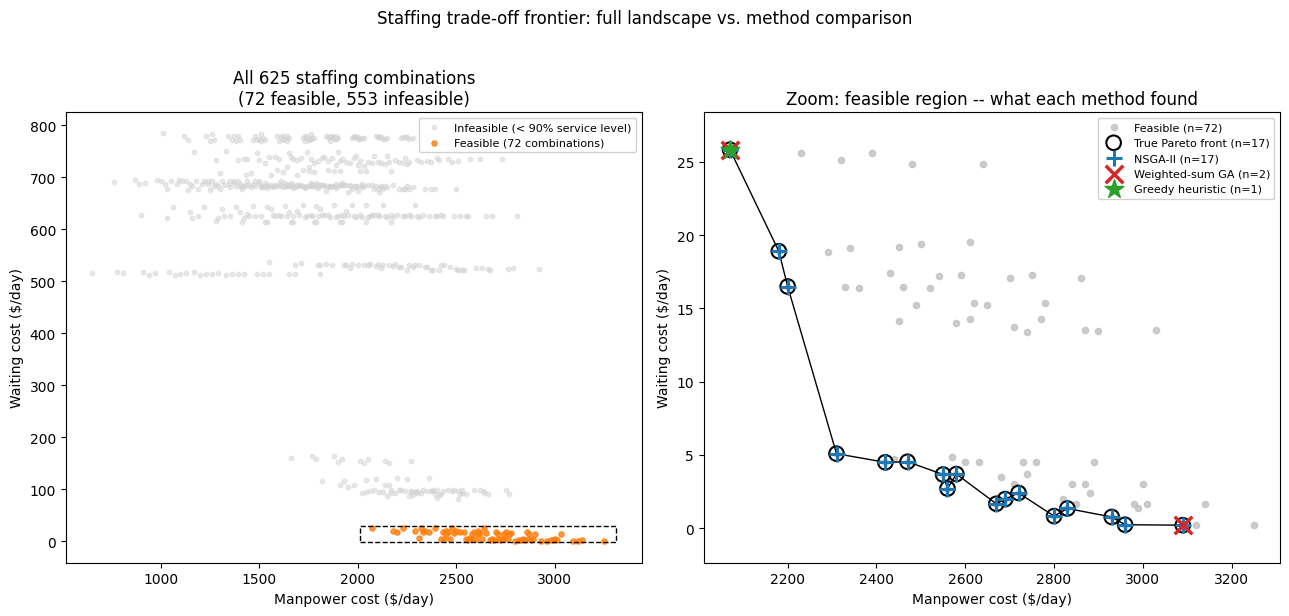

Saved: figures/method_comparison_front.png


In [ ]:
FIGURE_DPI = 300

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

ax1.scatter(enum_all_df.loc[~enum_all_df.feasible, "manpower_cost"],
            enum_all_df.loc[~enum_all_df.feasible, "waiting_cost"],
            s=10, color="lightgray", alpha=0.5, label="Infeasible (< 90% service level)")
ax1.scatter(enum_feasible_df.manpower_cost, enum_feasible_df.waiting_cost,
            s=14, color="tab:orange", alpha=0.8, label=f"Feasible ({len(enum_feasible_df)} combinations)")
ax1.set_xlabel("Manpower cost ($/day)")
ax1.set_ylabel("Waiting cost ($/day)")
ax1.set_title(f"All {len(enum_all_df)} staffing combinations\n"
              f"({len(enum_feasible_df)} feasible, {len(enum_all_df)-len(enum_feasible_df)} infeasible)")
ax1.legend(loc="upper right", fontsize=8, framealpha=0.9)

pad_x = 0.05 * (enum_feasible_df.manpower_cost.max() - enum_feasible_df.manpower_cost.min())
pad_y = 0.10 * (enum_feasible_df.waiting_cost.max() - enum_feasible_df.waiting_cost.min())
zoom_xlim = (enum_feasible_df.manpower_cost.min() - pad_x, enum_feasible_df.manpower_cost.max() + pad_x)
zoom_ylim = (enum_feasible_df.waiting_cost.min() - pad_y, enum_feasible_df.waiting_cost.max() + pad_y)
from matplotlib.patches import Rectangle
ax1.add_patch(Rectangle((zoom_xlim[0], zoom_ylim[0]), zoom_xlim[1]-zoom_xlim[0], zoom_ylim[1]-zoom_ylim[0],
                         fill=False, edgecolor="black", linestyle="--", linewidth=1))

ax2.scatter(enum_feasible_df.manpower_cost, enum_feasible_df.waiting_cost,
            s=20, color="silver", alpha=0.8, label=f"Feasible (n={len(enum_feasible_df)})", zorder=1)
ax2.plot(enum_front_df.manpower_cost, enum_front_df.waiting_cost, "-", color="black", linewidth=1, zorder=2)
ax2.scatter(enum_front_df.manpower_cost, enum_front_df.waiting_cost, s=110, marker="o",
            facecolors="none", edgecolors="black", linewidths=1.5, zorder=3,
            label=f"True Pareto front (n={len(enum_front_df)})")
ax2.scatter(nsga2_front_df.manpower_cost, nsga2_front_df.waiting_cost, s=130, marker="+",
            color="tab:blue", linewidths=2.2, zorder=4, label=f"NSGA-II (n={len(nsga2_front_df)})")
ax2.scatter(ga_front_df.manpower_cost, ga_front_df.waiting_cost, s=160, marker="x",
            color="tab:red", linewidths=2.5, zorder=5, label=f"Weighted-sum GA (n={len(ga_front_df)})")
ax2.scatter([heuristic_final["manpower_cost"]], [heuristic_final["waiting_cost"]], s=200, marker="*",
            color="tab:green", zorder=6, label="Greedy heuristic (n=1)")
ax2.set_xlim(*zoom_xlim)
ax2.set_ylim(*zoom_ylim)
ax2.set_xlabel("Manpower cost ($/day)")
ax2.set_ylabel("Waiting cost ($/day)")
ax2.set_title("Zoom: feasible region -- what each method found")
ax2.legend(loc="upper right", fontsize=8, framealpha=0.9)

fig.suptitle("Staffing trade-off frontier: full landscape vs. method comparison", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "method_comparison_front.png", dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()
print("Saved:", FIGURES_DIR / "method_comparison_front.png")

## 9. Summary

Headline numbers this notebook reproduces (compare against the paper's Results
section):

In [ ]:
print(f"Enumeration: {len(enum_feasible_df)}/625 feasible ({100*len(enum_feasible_df)/625:.1f}%), "
      f"true front = {len(enum_front_df)} solutions, runtime {enum_runtime:.1f}s")
print(f"Weighted-sum GA: {len(ga_front_df)} solutions found, runtime {ga_runtime:.1f}s")
print(f"NSGA-II: {len(nsga2_front_df)} solutions found ({len(nsga2_set & enum_set)}/{len(enum_set)} match true front), "
      f"runtime {nsga2_runtime:.1f}s")
print(f"Greedy heuristic: 1 solution ({'on' if is_on_true_front else 'off'} true front), runtime {heuristic_runtime:.1f}s")
print()
print(comparison_df.to_string(index=False))

Enumeration: 72/625 feasible (11.5%), true front = 17 solutions, runtime 23.9s
Weighted-sum GA: 2 solutions found, runtime 301.6s
NSGA-II: 17 solutions found (17/17 match true front), runtime 119.7s
Greedy heuristic: 1 solution (on true front), runtime 1.3s

                            Method  Solutions found                                                                                 Notes
            Exhaustive enumeration               17                                 Ground truth -- evaluates all 625 combinations in 24s
Weighted-sum GA (8 weight vectors)                2                                                  Found 2/17 true front points in 302s
        NSGA-II (Deb et al., 2002)               17                                                 Found 17/17 true front points in 120s
       Greedy bottleneck heuristic                1 1 point in 1s; on the true front, but structurally cannot reveal the other trade-offs
